# 03 — Sentiment Modelling

Inputs: `../data/grab_reviews_clean.csv`  
Outputs: `../models/distilbert-grab/`, `../data/grab_reviews_with_predictions.csv`

Pipeline:
1. VADER baseline (rule-based, no training)
2. DistilBERT fine-tune on 3-class sentiment (negative / neutral / positive)
3. Evaluate both with Precision / Recall / F1 per class

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

warnings.filterwarnings('ignore')
os.makedirs('../models', exist_ok=True)

df = pd.read_csv('../data/grab_reviews_clean.csv', parse_dates=['date'])
print(f'Loaded {len(df):,} reviews')
print(df['sentiment'].value_counts())

Loaded 5,333 reviews
sentiment
negative    2724
positive    2372
neutral      237
Name: count, dtype: int64


## 1. VADER Baseline

In [2]:
import nltk
nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_label(text: str) -> str:
    compound = sia.polarity_scores(text)['compound']
    if compound <= -0.05:
        return 'negative'
    elif compound >= 0.05:
        return 'positive'
    return 'neutral'

df['vader_pred'] = df['review_clean'].apply(vader_label)

print('VADER Classification Report:')
print(classification_report(df['sentiment'], df['vader_pred'], digits=3))

VADER Classification Report:
              precision    recall  f1-score   support

    negative      0.887     0.646     0.747      2724
     neutral      0.065     0.215     0.100       237
    positive      0.757     0.819     0.787      2372

    accuracy                          0.704      5333
   macro avg      0.570     0.560     0.545      5333
weighted avg      0.792     0.704     0.736      5333



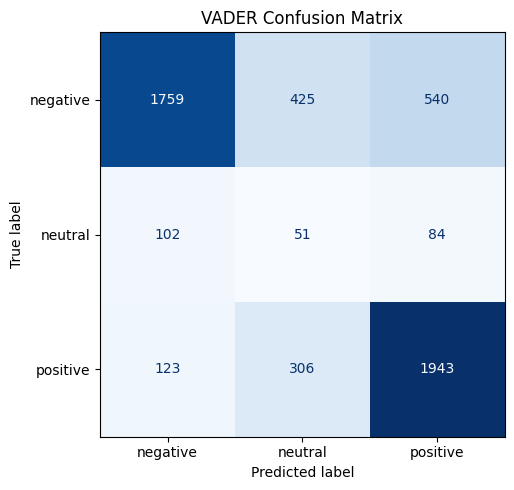

In [3]:
cm_vader = confusion_matrix(df['sentiment'], df['vader_pred'], labels=['negative', 'neutral', 'positive'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_vader, display_labels=['negative', 'neutral', 'positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('VADER Confusion Matrix')
plt.tight_layout()
plt.savefig('../data/03_vader_cm.png', dpi=120)
plt.show()

## 2. DistilBERT Fine-tuning

> **Tip:** Run on a GPU (Google Colab / local CUDA) for faster training.  
> On CPU, reduce `MAX_EPOCHS` to 1 and `SAMPLE_SIZE` to ~2000 for a quick check.

In [4]:
import torch
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from datasets import Dataset

DEVICE     = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128
MAX_EPOCHS = 1
BATCH_SIZE = 16
SAMPLE_SIZE = 2000   # subsampled for CPU training; set to None to use full dataset

print(f'Using device: {DEVICE}')

OSError: [WinError 1114] A dynamic link library (DLL) initialization routine failed. Error loading "c:\Users\siewy\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\lib\c10.dll" or one of its dependencies.

In [ ]:
label2id = {'negative': 0, 'neutral': 1, 'positive': 2}
id2label = {v: k for k, v in label2id.items()}

df_model = df[['review_clean', 'sentiment']].dropna().copy()
df_model['label'] = df_model['sentiment'].map(label2id)

if SAMPLE_SIZE:
    df_model = df_model.sample(SAMPLE_SIZE, random_state=42)

train_df, test_df = train_test_split(df_model, test_size=0.2, stratify=df_model['label'], random_state=42)
train_df, val_df  = train_test_split(train_df, test_size=0.1, stratify=train_df['label'], random_state=42)

print(f'Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Train: 3,839 | Val: 427 | Test: 1,067


In [ ]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['review_clean'], truncation=True, max_length=MAX_LEN)

def to_hf_dataset(df_):
    ds = Dataset.from_pandas(df_[['review_clean', 'label']].reset_index(drop=True))
    return ds.map(tokenize, batched=True)

train_ds = to_hf_dataset(train_df)
val_ds   = to_hf_dataset(val_df)
test_ds  = to_hf_dataset(test_df)

print('Datasets ready.')

Map:   0%|          | 0/3839 [00:00<?, ? examples/s]

Map:   0%|          | 0/427 [00:00<?, ? examples/s]

Map:   0%|          | 0/1067 [00:00<?, ? examples/s]

Datasets ready.


In [ ]:
from sklearn.metrics import f1_score, accuracy_score
import transformers

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'f1_macro':  f1_score(labels, preds, average='macro'),
        'accuracy':  accuracy_score(labels, preds),
    }

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)

_major, _minor = [int(x) for x in transformers.__version__.split('.')[:2]]
_eval_kwarg = 'eval_strategy' if (_major > 4 or (_major == 4 and _minor >= 41)) else 'evaluation_strategy'
_tok_kwarg  = 'processing_class' if _major >= 5 else 'tokenizer'

training_args = TrainingArguments(
    output_dir='../models/distilbert-grab',
    num_train_epochs=MAX_EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    warmup_steps=int(0.1 * (len(train_ds) // BATCH_SIZE * MAX_EPOCHS)),
    weight_decay=0.01,
    learning_rate=2e-5,
    **{_eval_kwarg: 'epoch'},
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    logging_steps=50,
    report_to='none',
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    **{_tok_kwarg: tokenizer},
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print(f'transformers {transformers.__version__} — using {_eval_kwarg}, {_tok_kwarg}')
print('Starting training...')
trainer.train()

## 3. Evaluate on Test Set

In [ ]:
predictions = trainer.predict(test_ds)
preds = np.argmax(predictions.predictions, axis=1)
true  = predictions.label_ids

print('DistilBERT Classification Report:')
print(classification_report(true, preds, target_names=['negative', 'neutral', 'positive'], digits=3))

  0%|          | 0/67 [00:00<?, ?it/s]

DistilBERT Classification Report:
              precision    recall  f1-score   support

    negative      0.879     0.961     0.918       545
     neutral      0.000     0.000     0.000        47
    positive      0.932     0.924     0.928       475

    accuracy                          0.903      1067
   macro avg      0.604     0.629     0.616      1067
weighted avg      0.864     0.903     0.882      1067



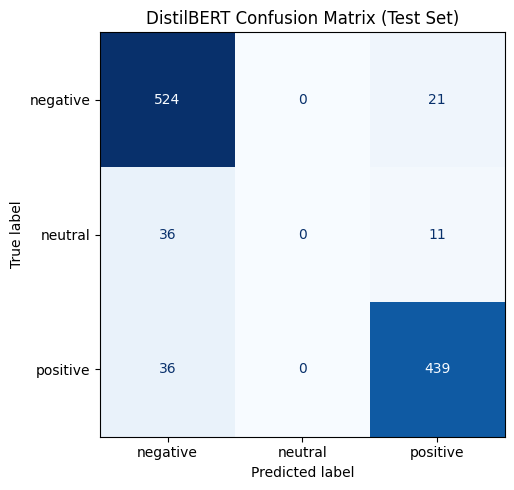

In [ ]:
cm_bert = confusion_matrix(true, preds)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_bert, display_labels=['negative', 'neutral', 'positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp2.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('DistilBERT Confusion Matrix (Test Set)')
plt.tight_layout()
plt.savefig('../data/03_distilbert_cm.png', dpi=120)
plt.show()

## 4. Predict on Full Dataset and Save

In [ ]:
from transformers import pipeline as hf_pipeline

classifier = hf_pipeline(
    'text-classification',
    model=model,
    tokenizer=tokenizer,
    device=0 if DEVICE == 'cuda' else -1,
    truncation=True,
    max_length=MAX_LEN,
    batch_size=32,
)

results = classifier(df['review_clean'].tolist())
df['bert_pred']  = [r['label'] for r in results]
df['bert_score'] = [r['score'] for r in results]

df.to_csv('../data/grab_reviews_with_predictions.csv', index=False)
print(f'Saved predictions to ../data/grab_reviews_with_predictions.csv')
df[['review_clean', 'sentiment', 'vader_pred', 'bert_pred', 'bert_score']].head()

Saved predictions to ../data/grab_reviews_with_predictions.csv


,review_clean,sentiment,vader_pred,bert_pred,bert_score
0,"Got scam by the app, put in an order waited ov...",negative,negative,negative,0.975653
1,The app is well designed and easy to use . How...,positive,positive,positive,0.993761
2,DO NOT pay with debit card. This app NEVER ref...,negative,negative,negative,0.971614
3,Great app in many regards. But please can you ...,positive,positive,positive,0.993714
4,convenient and user friendly.,positive,positive,positive,0.995062


## 5. Save Model

In [ ]:
trainer.save_model('../models/distilbert-grab')
tokenizer.save_pretrained('../models/distilbert-grab')
print('Model saved to ../models/distilbert-grab/')

Model saved to ../models/distilbert-grab/
